コロナ陽性かどうかの判定をします

In [213]:
# ライブラリのインポート
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [214]:
# データの読み込み（Covid Data.csvを読み込む）
dataset = pd.read_csv('Covid Data.csv')
dataset.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,1,6,2,2,9999-99-99,2,2,8,97,2,...,2,2,2,2,2,1,2,2,7,1
1,1,12,1,2,9999-99-99,2,1,51,2,1,...,2,2,1,2,1,1,1,2,7,2
2,2,4,1,1,9999-99-99,97,2,34,2,2,...,2,2,2,2,2,2,2,2,7,97
3,1,12,1,1,9999-99-99,97,2,40,2,2,...,2,2,2,2,2,2,2,2,3,97
4,2,12,2,1,9999-99-99,97,2,48,97,2,...,2,2,2,2,2,1,2,1,7,97


In [215]:
# データフレームのサイズを確認
print("元のデータフレームのサイズ:", dataset.shape)

元のデータフレームのサイズ: (180351, 21)


In [216]:
# ランダムに10分の1のサンプルを抽出
df_sampled = dataset.sample(frac=0.1, random_state=0)  
# サンプリングされたデータフレームのサイズを確認
print("サンプリングされたデータフレームのサイズ:", df_sampled.shape)

サンプリングされたデータフレームのサイズ: (18035, 21)


In [217]:
# サンプリングされたデータフレームを新しいCSVファイルに保存
df_sampled.to_csv('Covid Data_sampled.csv', index=False)
df_sampled.info()


<class 'pandas.core.frame.DataFrame'>
Index: 18035 entries, 6007 to 12269
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   USMER                 18035 non-null  int64 
 1   MEDICAL_UNIT          18035 non-null  int64 
 2   SEX                   18035 non-null  int64 
 3   PATIENT_TYPE          18035 non-null  int64 
 4   DATE_DIED             18035 non-null  object
 5   INTUBED               18035 non-null  int64 
 6   PNEUMONIA             18035 non-null  int64 
 7   AGE                   18035 non-null  int64 
 8   PREGNANT              18035 non-null  int64 
 9   DIABETES              18035 non-null  int64 
 10  COPD                  18035 non-null  int64 
 11  ASTHMA                18035 non-null  int64 
 12  INMSUPR               18035 non-null  int64 
 13  HIPERTENSION          18035 non-null  int64 
 14  OTHER_DISEASE         18035 non-null  int64 
 15  CARDIOVASCULAR        18035 non-null  

In [218]:
df_sampled.dtypes

USMER                    int64
MEDICAL_UNIT             int64
SEX                      int64
PATIENT_TYPE             int64
DATE_DIED               object
INTUBED                  int64
PNEUMONIA                int64
AGE                      int64
PREGNANT                 int64
DIABETES                 int64
COPD                     int64
ASTHMA                   int64
INMSUPR                  int64
HIPERTENSION             int64
OTHER_DISEASE            int64
CARDIOVASCULAR           int64
OBESITY                  int64
RENAL_CHRONIC            int64
TOBACCO                  int64
CLASIFFICATION_FINAL     int64
ICU                      int64
dtype: object

In [219]:
# 性別の変換
df_sampled['SEX'] = df_sampled['SEX'].map({1: 0, 2: 1})  # 1 = female, 2 = male

# 97と98をNaNに置き換え
df_sampled = df_sampled.replace(98, np.nan)
df_sampled = df_sampled.replace(97, np.nan)

# CLASIFFICATION_FINAL 値を1と0に変換 (1-3を1, それ以外を0)
df_sampled['CLASIFFICATION_FINAL'] = df_sampled['CLASIFFICATION_FINAL'].map({1: 1, 2: 1, 3: 1, 4: 0, 5: 0, 6: 0, 7: 0})

df_sampled.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
6007,1,4,0,1,9999-99-99,NaN,2,42.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0,NaN
65052,1,12,1,2,03/07/2020,1.0,1,34.0,NaN,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,0,1.0
176014,2,4,0,1,9999-99-99,NaN,2,19.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0,NaN
119046,2,12,0,1,9999-99-99,NaN,2,40.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0,NaN
154875,2,12,0,1,9999-99-99,NaN,2,34.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0,NaN


In [220]:
# 欠損値の数を再確認
df_sampled.isnull().sum()

USMER                       0
MEDICAL_UNIT                0
SEX                         0
PATIENT_TYPE                0
DATE_DIED                   0
INTUBED                 14535
PNEUMONIA                   0
AGE                         4
PREGNANT                 9179
DIABETES                   47
COPD                       46
ASTHMA                     45
INMSUPR                    46
HIPERTENSION               46
OTHER_DISEASE              79
CARDIOVASCULAR             46
OBESITY                    41
RENAL_CHRONIC              41
TOBACCO                    46
CLASIFFICATION_FINAL        0
ICU                     14535
dtype: int64

In [221]:
# 欠損値が多すぎる列の削除
df_sampled = df_sampled.drop(['DATE_DIED', 'INTUBED', 'PREGNANT', 'ICU'], axis=1)

In [222]:
# 最頻値で補完
for column in ['MEDICAL_UNIT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO']:
    df_sampled[column] = df_sampled[column].fillna(df_sampled[column].mode()[0])

# 平均値で補完
df_sampled['AGE'] = df_sampled['AGE'].fillna(df_sampled['AGE'].mean())

# 欠損値の再確認
print(df_sampled.isnull().sum())

USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
PNEUMONIA               0
AGE                     0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC           0
TOBACCO                 0
CLASIFFICATION_FINAL    0
dtype: int64


In [223]:
# CLASIFFICATION_FINALが1である割合を計算
positive_rate = df_sampled['CLASIFFICATION_FINAL'].value_counts(normalize=True)[1] * 100

print(f"陽性の割合: {positive_rate:.2f}%")

陽性の割合: 40.52%


In [224]:
import tensorflow as tf
from tensorflow import keras

In [225]:
# モデル構築
from sklearn.model_selection import train_test_split

# 説明変数と目的変数を指定
X = df_sampled.drop('CLASIFFICATION_FINAL', axis=1)
y = df_sampled['CLASIFFICATION_FINAL']
print(df_sampled['CLASIFFICATION_FINAL'].value_counts(normalize=True))


CLASIFFICATION_FINAL
0    0.594788
1    0.405212
Name: proportion, dtype: float64


In [226]:
# 学習データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (12624, 16)
X_test shape: (5411, 16)
y_train shape: (12624,)
y_test shape: (5411,)


In [227]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [228]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

In [229]:
# モデルの初期化
model = keras.Sequential([
    keras.layers.Dense(128, activation='elu', input_shape=(X_train.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='elu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='elu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

# オプティマイザーの設定
optimizer = Adam(learning_rate=0.005)

# モデルの構築
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

c:\Users\mizuishi.DSC-DEV14\work\テックアカデミー\aidev\.venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [230]:
# モデルの構造を表示
model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_94 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 12,993 (50.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [231]:
# EarlyStoppingの設定
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# モデルの学習
log = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, class_weight={0: 0.4, 1: 0.6}, callbacks=[early_stopping])

Epoch 1/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5596 - loss: 0.3627 - val_accuracy: 0.5861 - val_loss: 0.6679
Epoch 2/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5824 - loss: 0.3235 - val_accuracy: 0.5996 - val_loss: 0.6630
Epoch 3/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5906 - loss: 0.3192 - val_accuracy: 0.6016 - val_loss: 0.6592
Epoch 4/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5954 - loss: 0.3196 - val_accuracy: 0.5949 - val_loss: 0.6687
Epoch 5/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6011 - loss: 0.3212 - val_accuracy: 0.6242 - val_loss: 0.6589
Epoch 6/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6097 - loss: 0.3192 - val_accuracy: 0.6265 - val_loss: 0.6509
Epoch 7/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6081 - loss: 0.3169 - val_accuracy: 0.6095 - val_loss: 0.6607
Epoch 8/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5986 - loss: 0.3188 - val_accu

In [232]:
from sklearn.metrics import classification_report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.66      0.74      0.70      3188
           1       0.55      0.47      0.51      2223

    accuracy                           0.62      5411
   macro avg       0.61      0.60      0.60      5411
weighted avg       0.62      0.62      0.62      5411



170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step
AUC: 0.642


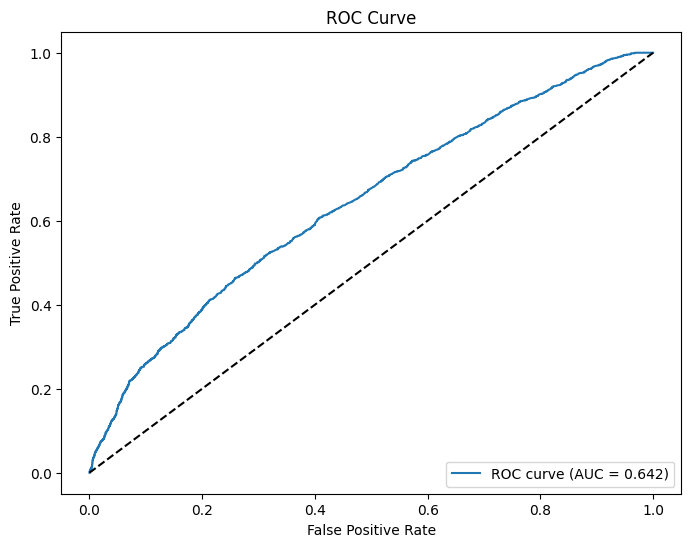

In [233]:
from sklearn.metrics import roc_curve, auc
y_pred_prob = model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.3f}")

# グラフ表示
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [235]:
# 異なる閾値での予測結果を確認
thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7]
for threshold in thresholds_to_try:
    y_pred = (model.predict(X_test) > threshold).astype(int)
    print(f"閾値 {threshold}:")
    print(classification_report(y_test, y_pred))
    print("---")

170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
閾値 0.3:
              precision    recall  f1-score   support

           0       0.90      0.06      0.11      3188
           1       0.42      0.99      0.59      2223

    accuracy                           0.44      5411
   macro avg       0.66      0.53      0.35      5411
weighted avg       0.70      0.44      0.31      5411

---
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
閾値 0.4:
              precision    recall  f1-score   support

           0       0.73      0.28      0.40      3188
           1       0.45      0.85      0.59      2223

    accuracy                           0.51      5411
   macro avg       0.59      0.56      0.50      5411
weighted avg       0.61      0.51      0.48      5411

---
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
閾値 0.5:
              precision    recall  f1-score   support

           0       0.66      0.74      0.70      3188
           1       0.55      0.47      0.51      2223

    accuracy               